In [1]:
import glob
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


solver_type = 'Advantage2_system1.8'
case_path = '../results/{}/{}/send_{}/m{}/case{}/beta{}/{}_{}_num_reads_{}.json'
case_path_GW = '../results/{}/{}/send_{}/m{}/case{}/beta{}/{}_{}.json'

biqbin_result_mask = '../results/Advantage2_system1.8/Biqbin/*{}.json.output.json'



#list_of_cases = sorted(glob.glob(case_path.format(solver_type, '*', 1, 0, 0.0)))
list_of_cases_QA_J_log_100 = sorted(glob.glob(case_path.format(solver_type, 'QA', '*', '*', '*', 0.0, 'QA', 'J_log', 100)))
list_of_cases_QA_J_qac_100 = sorted(glob.glob(case_path.format(solver_type, 'QA', '*', '*', '*', 0.0, 'QA', 'J_qac', 100)))

list_of_cases_GW_J_log = sorted(glob.glob(case_path_GW.format(solver_type, 'GW', '*', '*', '*', 0.0, 'GW', 'J_log')))
list_of_cases_GW_J_qac = sorted(glob.glob(case_path_GW.format(solver_type, 'GW', '*', '*', '*', 0.0, 'GW', 'J_qac')))

list_of_cases_SA_J_log_100 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_log', 100)))
list_of_cases_SA_J_qac_100 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_qac', 100)))
list_of_cases_SA_J_log_1000 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_log', 1000)))
list_of_cases_SA_J_qac_1000 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_qac', 1000)))

bidbin_result_files_J_log = glob.glob(biqbin_result_mask.format('J_log'))
bidbin_result_files_J_qac = glob.glob(biqbin_result_mask.format('J_qac'))



In [2]:
def flatten_dict(d, prefix='', level=0):
    for i,j in d.items():
        if isinstance(j, dict):
            yield from flatten_dict(j, f'{prefix}{i}_', level+1)
        else:
            yield f'{prefix}{i}', j


def get_result_data(result_files):
    for i in result_files:
        with open(i) as f:
            result = json.load(f)
        yield {'instance': i, 'value': result['value']}

def get_result_data_biqbin(result_files):
    for i in result_files:
        with open(i) as f:
            result = json.load(f)
        yield dict(flatten_dict(result))


QA_J_log_100 = pd.DataFrame(get_result_data(list_of_cases_QA_J_log_100))
QA_J_qac_100 = pd.DataFrame(get_result_data(list_of_cases_QA_J_qac_100))

GW_J_log = pd.DataFrame(get_result_data(list_of_cases_GW_J_log))
#GW_J_qac = pd.DataFrame(get_result_data(list_of_cases_GW_J_qac))

SA_J_log_100 = pd.DataFrame(get_result_data(list_of_cases_SA_J_log_100))
SA_J_qac_100 = pd.DataFrame(get_result_data(list_of_cases_SA_J_qac_100))
SA_J_log_1000 = pd.DataFrame(get_result_data(list_of_cases_SA_J_log_1000))
SA_J_qac_1000 = pd.DataFrame(get_result_data(list_of_cases_SA_J_qac_1000))

biqbin_result_J_log = pd.DataFrame(get_result_data_biqbin(bidbin_result_files_J_log))
biqbin_result_J_qac = pd.DataFrame(get_result_data_biqbin(bidbin_result_files_J_qac))


In [3]:
biqbin_result_J_log['instance_norm'] = biqbin_result_J_log['meta_data_instance'].apply(lambda x: x.replace('sidon/j_log/Advantage2_system1.8_send_8_', '').replace('_case', '/case').replace('_beta', '/beta').replace('_J', '/_J'))
biqbin_result_J_qac['instance_norm'] = biqbin_result_J_qac['meta_data_instance'].apply(lambda x: x.replace('sidon/j_log/Advantage2_system1.8_send_8_', '').replace('_case', '/case').replace('_beta', '/beta').replace('_J', '/_J'))

biqbin_result_J_log['value'] = biqbin_result_J_log['qubo_computed_val'] / 28
biqbin_result_J_qac['value'] = biqbin_result_J_qac['qubo_computed_val'] / 28


In [4]:
GW_J_log['instance_norm'] = GW_J_log['instance'].apply(lambda x: x.replace('GW', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
#GW_J_qac['instance_norm'] = GW_J_qac['instance'].apply(lambda x: x.replace('GW', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))


QA_J_log_100['instance_norm'] = QA_J_log_100['instance'].apply(lambda x: x.replace('QA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
QA_J_qac_100['instance_norm'] = QA_J_qac_100['instance'].apply(lambda x: x.replace('QA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
QA_J_log_100['num_reads'] = 100
QA_J_qac_100['num_reads'] = 100


SA_J_log_100['instance_norm'] = SA_J_log_100['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_qac_100['instance_norm'] = SA_J_qac_100['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_log_100['num_reads'] = 100
SA_J_qac_100['num_reads'] = 100

SA_J_log_1000['instance_norm'] = SA_J_log_1000['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_1000', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_qac_1000['instance_norm'] = SA_J_qac_1000['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_1000', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_log_1000['num_reads'] = 1000
SA_J_qac_1000['num_reads'] = 1000

GW_J_log.drop('instance', axis=1, inplace=True)
#GW_J_qac.drop('instance', axis=1, inplace=True)
QA_J_log_100.drop('instance', axis=1, inplace=True)
QA_J_qac_100.drop('instance', axis=1, inplace=True)
SA_J_log_100.drop('instance', axis=1, inplace=True)
SA_J_qac_100.drop('instance', axis=1, inplace=True)
SA_J_log_1000.drop('instance', axis=1, inplace=True)
SA_J_qac_1000.drop('instance', axis=1, inplace=True)


In [5]:
J_log_QA = QA_J_log_100.merge(SA_J_log_100, on='instance_norm', how='left', suffixes=('', '_SA_100'))
J_log_QA = J_log_QA.merge(SA_J_log_1000, on='instance_norm', how='left', suffixes=('', '_SA_1000'))
J_log_QA = J_log_QA.merge(GW_J_log, on='instance_norm', how='left', suffixes=('', '_GW'))

J_log_QA = J_log_QA.merge(biqbin_result_J_log, on='instance_norm', how='left', suffixes=('', '_biqbin'))




In [6]:
J_log_QA['err_abs_value_SA_100'] = -(J_log_QA['value']-J_log_QA['value_SA_100'])
J_log_QA['err_abs_value_SA_1000'] = -(J_log_QA['value']-J_log_QA['value_SA_1000'])
J_log_QA['err_abs_value_GW'] = -(J_log_QA['value']-J_log_QA['value_GW'])
J_log_QA['err_abs_value_biqbin'] = -(J_log_QA['value']-J_log_QA['value_biqbin'])

J_log_QA['err_rel_value_SA_100'] = J_log_QA['err_abs_value_SA_100']/J_log_QA['value'].abs()*100
J_log_QA['err_rel_value_SA_1000'] = J_log_QA['err_abs_value_SA_1000']/J_log_QA['value'].abs()*100
J_log_QA['err_rel_value_GW'] = J_log_QA['err_abs_value_GW']/J_log_QA['value'].abs()*100
J_log_QA['err_rel_value_biqbin'] = J_log_QA['err_abs_value_biqbin']/J_log_QA['value'].abs()*100

J_log_QA['m'] = (J_log_QA['instance_norm'].apply(lambda x: int(x.split('/')[0].replace('m', ''))))
J_log_QA = J_log_QA.sort_values(['m'])

<Figure size 640x480 with 0 Axes>

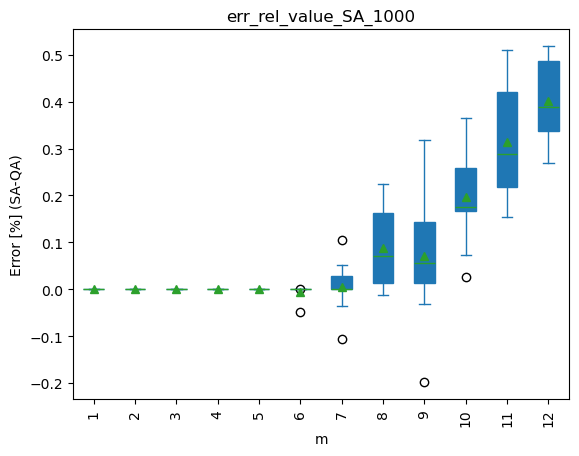

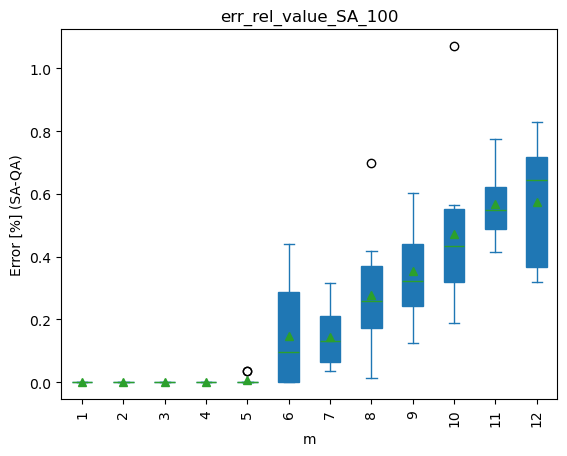

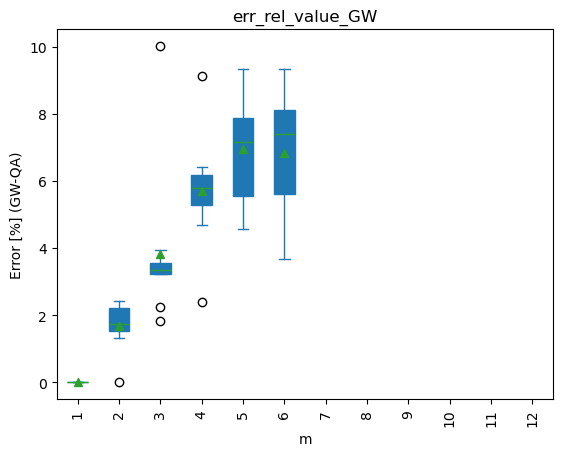

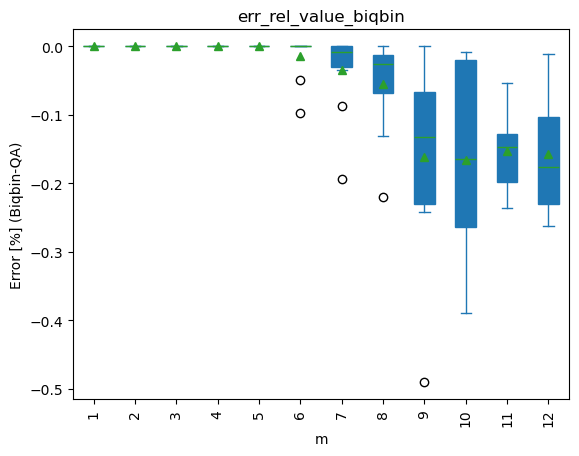

In [7]:
# We compare aginst QA!!!

myFig = plt.figure()
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_SA_1000', by=['m'], xlabel='m', ylabel='Error [%] (SA-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_SA_100', by=['m'], xlabel='m', ylabel='Error [%] (SA-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_GW', by=['m'], xlabel='m', ylabel='Error [%] (GW-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_biqbin', by=['m'], xlabel='m', ylabel='Error [%] (Biqbin-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)

In [8]:
# We compare against Biqbin!

J_log_QA['biqbin_err_abs_value_SA_100'] = -(J_log_QA['value_biqbin']-J_log_QA['value_SA_100'])
J_log_QA['biqbin_err_abs_value_SA_1000'] = -(J_log_QA['value_biqbin']-J_log_QA['value_SA_1000'])
J_log_QA['biqbin_err_abs_value_GW'] = -(J_log_QA['value_biqbin']-J_log_QA['value_GW'])
J_log_QA['biqbin_err_abs_value_QA'] = -(J_log_QA['value_biqbin']-J_log_QA['value'])

J_log_QA['biqbin_err_rel_value_SA_100'] = J_log_QA['biqbin_err_abs_value_SA_100']/J_log_QA['value_biqbin'].abs()*100
J_log_QA['biqbin_err_rel_value_SA_1000'] = J_log_QA['biqbin_err_abs_value_SA_1000']/J_log_QA['value_biqbin'].abs()*100
J_log_QA['biqbin_err_rel_value_GW'] = J_log_QA['biqbin_err_abs_value_GW']/J_log_QA['value_biqbin'].abs()*100
J_log_QA['biqbin_err_rel_value_QA'] = J_log_QA['biqbin_err_abs_value_QA']/J_log_QA['value_biqbin'].abs()*100

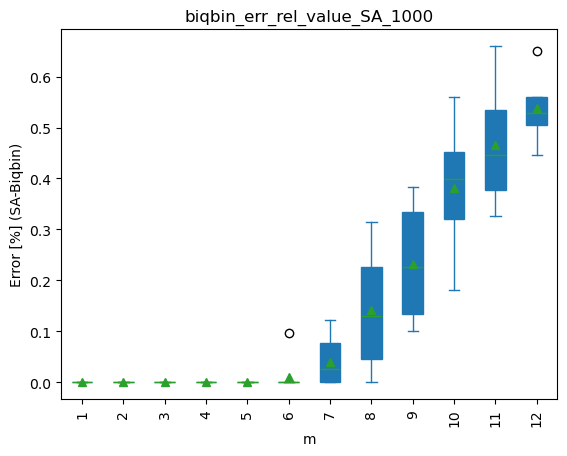

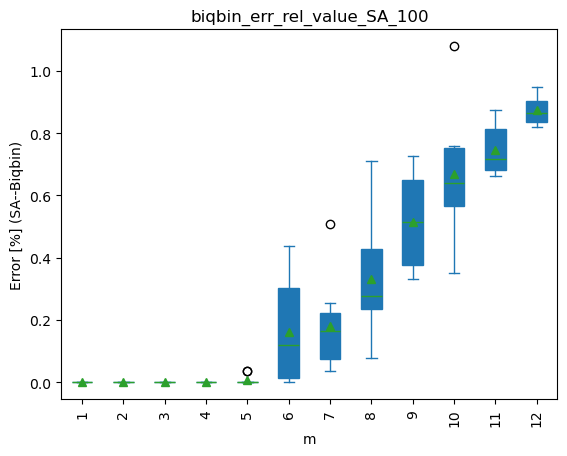

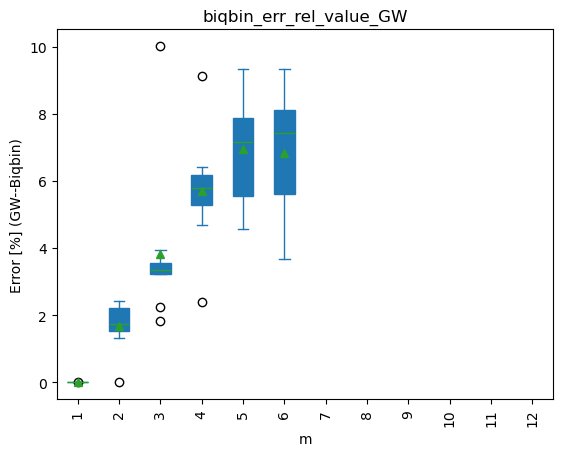

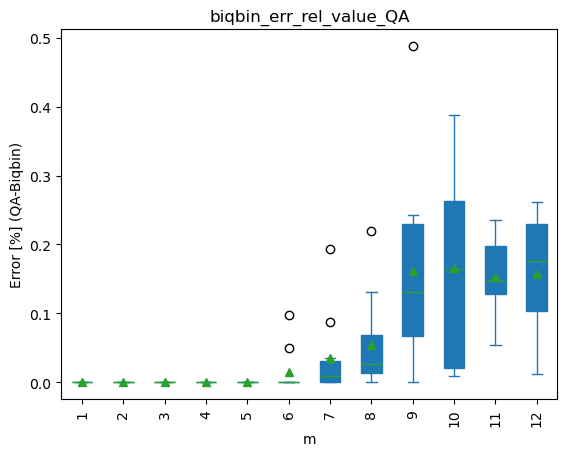

In [9]:
ax = J_log_QA.reset_index().plot.box(column='biqbin_err_rel_value_SA_1000', by=['m'], xlabel='m', ylabel='Error [%] (SA-Biqbin)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='biqbin_err_rel_value_SA_100', by=['m'], xlabel='m', ylabel='Error [%] (SA--Biqbin)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='biqbin_err_rel_value_GW', by=['m'], xlabel='m', ylabel='Error [%] (GW--Biqbin)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='biqbin_err_rel_value_QA', by=['m'], xlabel='m', ylabel='Error [%] (QA-Biqbin)', logy=False, showmeans=True, patch_artist=True, rot=90)

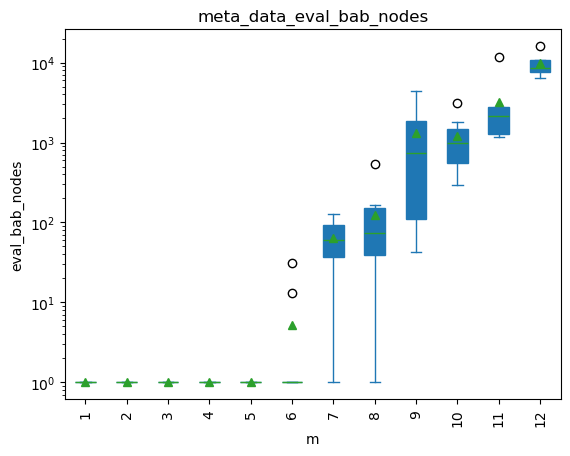

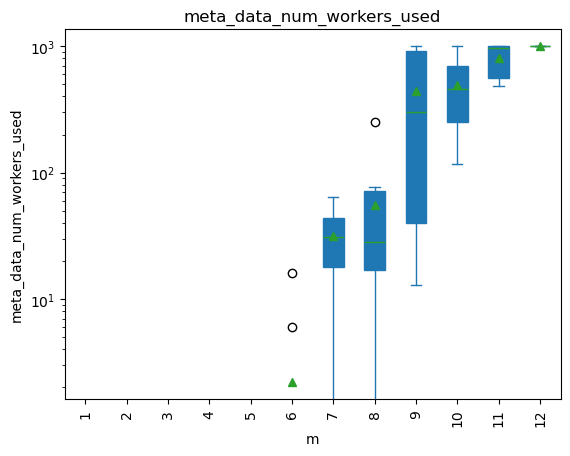

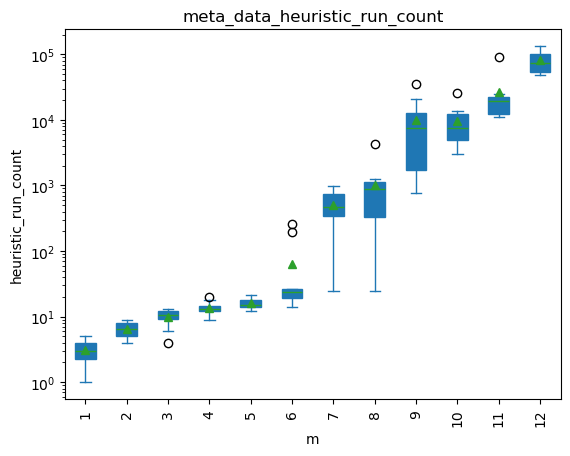

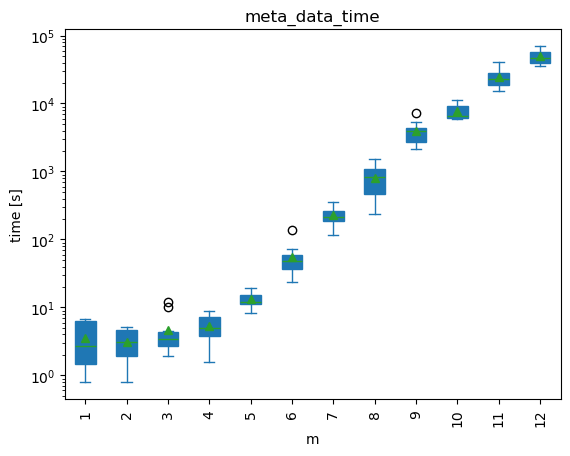

In [10]:
ax = J_log_QA.reset_index().plot.box(column='meta_data_eval_bab_nodes', by=['m'], xlabel='m', ylabel='eval_bab_nodes', logy=True, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='meta_data_num_workers_used', by=['m'], xlabel='m', ylabel='meta_data_num_workers_used', logy=True, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='meta_data_heuristic_run_count', by=['m'], xlabel='m', ylabel='heuristic_run_count', logy=True, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='meta_data_time', by=['m'], xlabel='m', ylabel='time [s]', logy=True, showmeans=True, patch_artist=True, rot=90)
